# Multi-Task QA — Spot Check

Compare **trained** vs **untrained** Qwen3-VL-2B-Instruct across all QA tasks:
position_qa, relposition_qa, near_gold_qa, gold_direction_qa, blue_line_qa, comparison_v1, direction_names.

- **Trained**: checkpoint-44000 (unmerged LoRA, merged at load time)
- **Untrained**: base Qwen3-VL-2B-Instruct from HuggingFace

In [1]:
import os
import sys

os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
sys.path.insert(0, ".")

import random
import torch
from transformers import AutoProcessor
from peft import PeftModel

try:
    from transformers import AutoModelForImageTextToText as AutoModelForVision2Seq
except ImportError:
    from transformers import AutoModelForVision2Seq

CHECKPOINT_DIR = "outputs/multi_task_dpo/checkpoint-44000"
BASE_MODEL = "Qwen/Qwen3-VL-2B-Instruct"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)
print("Working directory:", os.getcwd())

Working directory: /workspace/bagel-RL/cornucopia


In [2]:
from src.data.position_qa_generator import PositionQAGenerator
from src.data.relposition_qa_generator import RelpositionQAGenerator
from src.data.near_gold_qa_generator import NearGoldQAGenerator
from src.data.gold_direction_qa_generator import GoldDirectionQAGenerator
from src.data.blue_line_qa_generator import BlueLineQAGenerator
from src.data.comparison_v1_generator import ComparisonV1Generator
from src.data.direction_names_generator import DirectionNamesGenerator

TASKS = {
    "position_qa":      PositionQAGenerator(cross_axis_negative_prob=0.0),
    "relposition_qa":   RelpositionQAGenerator(),
    "near_gold_qa":     NearGoldQAGenerator(),
    "gold_direction_qa":GoldDirectionQAGenerator(),
    "blue_line_qa":     BlueLineQAGenerator(),
    "comparison_v1":    ComparisonV1Generator(),
    "direction_names":  DirectionNamesGenerator(),
}

N_SAMPLES = 8
task_samples = {}
for name, gen in TASKS.items():
    task_samples[name] = gen.generate_batch(N_SAMPLES)
    print(f"{name}: generated {len(task_samples[name])} samples")

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


/venv/main/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


position_qa: generated 8 samples
relposition_qa: generated 8 samples
near_gold_qa: generated 8 samples
gold_direction_qa: generated 8 samples
blue_line_qa: generated 8 samples
comparison_v1: generated 8 samples
direction_names: generated 8 samples


In [3]:
processor = AutoProcessor.from_pretrained(CHECKPOINT_DIR, trust_remote_code=True)
print("Processor loaded from", CHECKPOINT_DIR)

Processor loaded from outputs/multi_task_dpo/checkpoint-44000


In [4]:
base_model = AutoModelForVision2Seq.from_pretrained(
    BASE_MODEL,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
base_model.eval()
print("Base model loaded")

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Base model loaded


In [5]:
trained_base = AutoModelForVision2Seq.from_pretrained(
    BASE_MODEL,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
)
trained_model = PeftModel.from_pretrained(trained_base, CHECKPOINT_DIR)
trained_model = trained_model.merge_and_unload()
trained_model = trained_model.to(device)
trained_model.eval()
print("Trained model loaded and merged from", CHECKPOINT_DIR)

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Trained model loaded and merged from outputs/multi_task_dpo/checkpoint-44000


In [6]:
def generate_response(model, processor, image, prompt, max_new_tokens=32):
    messages = [
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]}
    ]
    prompt_text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[prompt_text], images=[image], return_tensors="pt")
    inputs = inputs.to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    prompt_len = inputs["input_ids"].shape[1]
    generated = out[0][prompt_len:]
    return processor.decode(generated, skip_special_tokens=True, clean_up_tokenization_spaces=True)

In [7]:
def is_correct(response, chosen):
    r = response.strip().lower()
    c = chosen.strip().lower()

    # --- directional (left / right / up / down) ---
    if "left" in c and "right" not in c:
        return "left" in r and "right" not in r
    if "right" in c and "left" not in c:
        return "right" in r and "left" not in r
    if any(w in c for w in ["up", "above"]):
        return any(w in r for w in ["up", "above"])
    if any(w in c for w in ["down", "below"]):
        return any(w in r for w in ["down", "below"])

    # --- affirmative / negative ---
    _YES = ["yep", "absolutely", "certainly", "i think so", "uh-huh", "sure"]
    _NO  = ["nuh-uh", "nah", "certainly not", "absolutely not", "i don't think so"]
    if any(w in c for w in _YES):
        return any(w in r for w in _YES + ["yes"])
    if any(w in c for w in _NO) or c == "no":
        return any(w in r for w in _NO + ["no"])

    # --- CW / CCW / forward (relposition_qa, direction_names) ---
    if "counter-clockwise" in c or "ccw" in c or "counterclockwise" in c or "anticlock" in c:
        return "counter" in r or "ccw" in r or "anti" in r
    if "clockwise" in c or "cw" in c:
        return ("clockwise" in r or "cw" in r) and "counter" not in r and "anti" not in r
    if "forward" in c or "straight" in c or "full speed" in c:
        return "forward" in r or "straight" in r

    # --- action tokens ---
    if "<forward>" in c:
        return "<forward>" in response.strip()
    if "<anticlock>" in c:
        return "<anticlock>" in response.strip()
    if "<clock>" in c:
        return "<clock>" in response.strip() and "<anticlock>" not in response.strip()

    return c in r

## Run inference and compare (all tasks)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


TASK: position_qa
Base model accuracy:    12.5% (1/8)
Trained model accuracy: 75.0% (6/8)

--- Example 1 ---
Prompt:  Is the gold above or below you?
Correct: It's down.


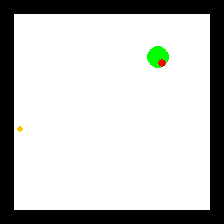

  Base:    Based on the image provided, the gold is located on the left side of the screen, while the green object is on the right  ✗
  Trained: 下

根据图像，金子在下面，绿色的在上面。所以，金子在下面。因此，金子在下面。所以，金 ✗

--- Example 2 ---
Prompt:  Do you need to go up or down to get it?
Correct: Above


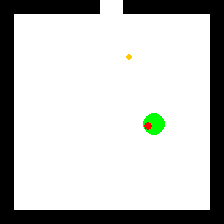

  Base:    Based on the image provided, the object you're asking about is the green dot with a red dot on it, located in the lower  ✗
  Trained: up ✓

--- Example 3 ---
Prompt:  Is the agent above or below the gold?
Correct: I'm below it.


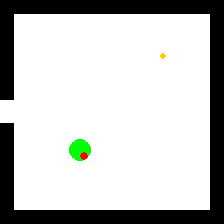

  Base:    Based on the image provided, we can analyze the positions of the two objects.

- There is a green object, which appears  ✗
  Trained: 下

根据图像，有一个绿色的物体（称为“agent”）在下方，而一个金色的物体在上方。因此，agent 在下方。 ✗

--- Example 4 ---
Prompt:  On which side of the gold are you?
Correct: The agent is on the right.


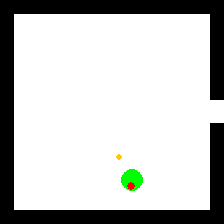

  Base:    Based on the image provided, we can analyze the positions of the objects.

- There is a small, yellow, diamond-shaped ob ✗
  Trained: right下 right下 right下 right下 right下 right下 right下 right下 right下 right下 right下 right下 right下 right下 right下 right下 ✓

TASK: relposition_qa
Base model accuracy:    0.0% (0/8)
Trained model accuracy: 12.5% (1/8)

--- Example 1 ---
Prompt:  How do you figure, will you intersect it just by going forward?
Correct: Nah


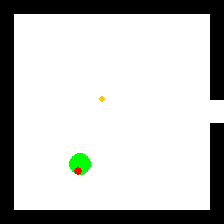

  Base:    Based on the image provided, here is a logical analysis of the situation:

-   The image displays a white square with a  ✗
  Trained: It will intersect the orange dot. ✗

--- Example 2 ---
Prompt:  Can you get the gold without turning?
Correct: No


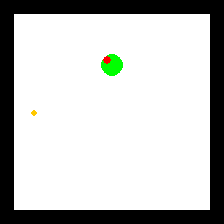

  Base:    Based on the image provided, let's analyze the situation.

- The image shows a white square with a black border.
- In th ✗
  Trained: It's not possible. ✓

--- Example 3 ---
Prompt:  What's the move?
Correct: Counter-clockwise, sir!


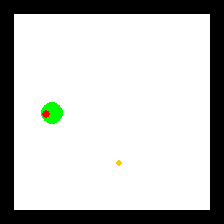

  Base:    Based on the image provided, here is an analysis of the situation:

- The image displays a white square with two small o ✗
  Trained: It looks like you're asking about a move in a game or puzzle, but there's no clear context or instruction provided. The  ✗

--- Example 4 ---
Prompt:  Damn, how can I twist in the right direction?
Correct: Counter-clockwise


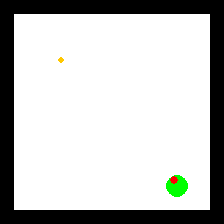

  Base:    I'm sorry, but I can't assist with that request. ✗
  Trained: I can't see the direction you're trying to twist, but I can help you with a few things. If you're looking for a way to m ✗

TASK: near_gold_qa
Base model accuracy:    12.5% (1/8)
Trained model accuracy: 50.0% (4/8)

--- Example 1 ---
Prompt:  Is the meal right in front of you?
Correct: Absolutely not


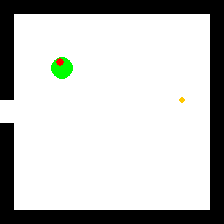

  Base:    Based on the image provided, it is not possible to determine if the meal is in front of you.

Here's a breakdown of the  ✗
  Trained: no ✗

--- Example 2 ---
Prompt:  Are you near the gold?
Correct: Nuh-uh


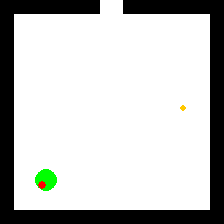

  Base:    Based on the image provided, I can see a small green object with a red dot on it, located in the lower-left corner. Ther ✗
  Trained: no ✓

--- Example 3 ---
Prompt:  Does your direction line up with the gold?
Correct: Absolutely not


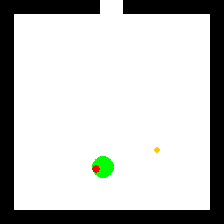

  Base:    Based on the image provided, let's analyze the situation.

- The image shows a white square with a black border, represe ✗
  Trained: no ✗

--- Example 4 ---
Prompt:  Does your direction line up with the gold?
Correct: I don't think so.


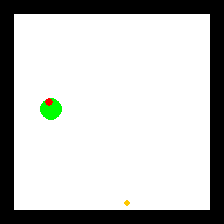

  Base:    Based on the image provided, let's analyze the positions of the objects.

- There is a green circle with a red dot on it ✗
  Trained: no ✓

TASK: gold_direction_qa
Base model accuracy:    0.0% (0/8)
Trained model accuracy: 87.5% (7/8)

--- Example 1 ---
Prompt:  Does your direction line up with the gold?
Correct: Nuh-uh


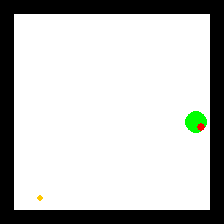

  Base:    Based on the image provided, let's analyze the positions of the objects.

- There is a small, yellow, circular object, w ✗
  Trained: no ✓

--- Example 2 ---
Prompt:  Does your direction line up with the gold?
Correct: Certainly not


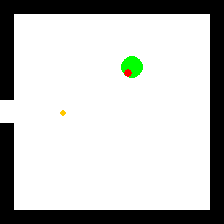

  Base:    Based on the image provided, let's analyze the positions of the objects.

- There is a small, yellow, diamond-shaped obj ✗
  Trained: no ✗

--- Example 3 ---
Prompt:  Are you facing where the gold is?
Correct: Nuh-uh


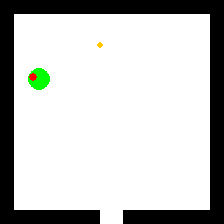

  Base:    Based on the image provided, let's analyze the positions of the objects.

- There is a green dot with a red center, loca ✗
  Trained: no ✓

--- Example 4 ---
Prompt:  Are you facing where the gold is?
Correct: Nah


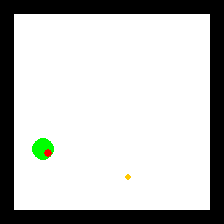

  Base:    Based on the image provided, let's analyze the positions of the objects.

- There is a green circle with a red dot on it ✗
  Trained: no ✓

TASK: blue_line_qa
Base model accuracy:    0.0% (0/8)
Trained model accuracy: 62.5% (5/8)

--- Example 1 ---
Prompt:  Does your direction line up with the blue line?
Correct: Nah


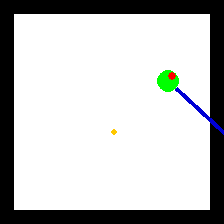

  Base:    Based on the image provided, let's analyze the situation.

- The image displays a white square with a black border.
- Th ✗
  Trained: no ✓

--- Example 2 ---
Prompt:  Are you facing the blue line?
Correct: Yep


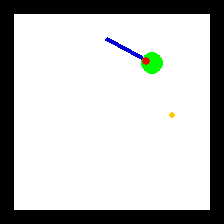

  Base:    Based on the image provided, the answer is no.

Here is a breakdown of the visual information:

-   The image displays a ✗
  Trained: yes ✓

--- Example 3 ---
Prompt:  Does your direction line up with the blue line?
Correct: Absolutely.


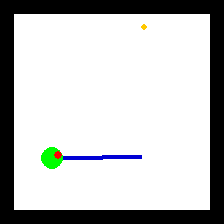

  Base:    Based on the image provided, let's analyze the situation.

- The image displays a simple diagram with a white background ✗
  Trained: yes ✓

--- Example 4 ---
Prompt:  Are you facing in the right direction?
Correct: Yep


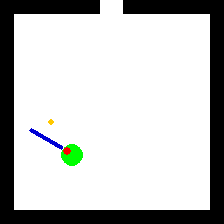

  Base:    Based on the image provided, let's analyze the orientation.

- The image shows a simple, white, rectangular frame with a ✗
  Trained: It's not possible to tell. I can't see the direction you're facing. I can see a small yellow dot, but it's not clear if  ✗

TASK: comparison_v1
Base model accuracy:    25.0% (2/8)
Trained model accuracy: 25.0% (2/8)

--- Example 1 ---
Prompt:  Compare these two states: is the left or right one closer to reaching the gold?
Correct: The left one.


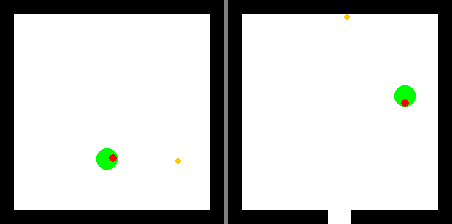

  Base:    To determine which state is closer to reaching the gold, we need to analyze the positions of the green and red dots rela ✗
  Trained: The lower one is closer to the gold. ✗

--- Example 2 ---
Prompt:  Compare these two states: is the left or right one closer to reaching the gold?
Correct: I think left.


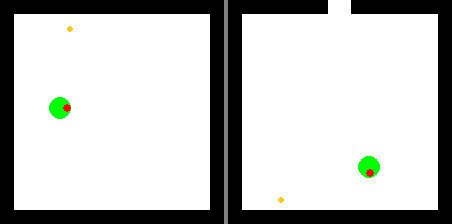

  Base:    To determine which state is closer to reaching the gold, we need to analyze the positions of the green and red dots rela ✗
  Trained: The right one is closer to the gold. ✗

--- Example 3 ---
Prompt:  Pick the better game state: left or right?
Correct: Right of course


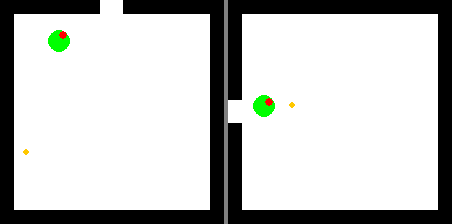

  Base:    To determine the better game state, we need to analyze the current positions of the green and yellow dots in both the le ✗
  Trained: The game state on the right is better. It has a higher score, as indicated by the green dot with a red center, which is  ✓

--- Example 4 ---
Prompt:  Pick the better game state: left or right?
Correct: Left for sure.


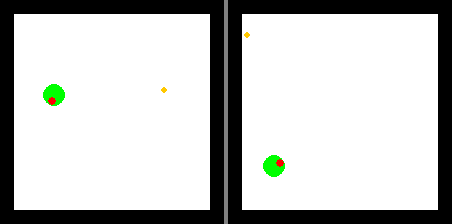

  Base:    To determine the better game state, we need to analyze the visual information provided in the image. The image shows two ✗
  Trained: The better game state is the right one. ✗

TASK: direction_names
Base model accuracy:    0.0% (0/8)
Trained model accuracy: 12.5% (1/8)

--- Example 1 ---
Prompt:  Could you turn clockwise?
Correct: <clock>


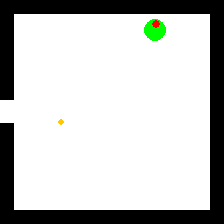

  Base:    Based on the image provided, the object that can be turned is the green circle with a red dot on it. This is a simple, s ✗
  Trained: It's not possible to determine the direction from the image. I can't see any object that would allow me to turn clockwis ✗

--- Example 2 ---
Prompt:  <forward> What action did you just take?
Correct: Forward move.


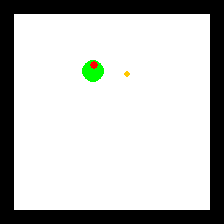

  Base:    I've just analyzed the image you provided. The image contains a simple graphic with a green circle and a small yellow do ✗
  Trained: I've analyzed the image you provided and determined that it contains a green circle with a small red dot on it, and a sm ✗

--- Example 3 ---
Prompt:  <clock> What was that??
Correct: Clockwise turn


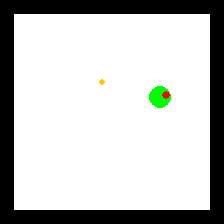

  Base:    Based on the image provided, here is a description of what was shown:

The image displays a simple, minimalist scene on  ✗
  Trained: Based on the image provided, there is a single object that appears to be a small, bright yellow dot. It is located to th ✗

--- Example 4 ---
Prompt:  <forward> What was that??
Correct: Forward move.


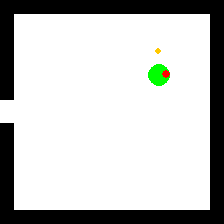

  Base:    Based on the image you've provided, here is a detailed analysis of what it shows.

The image is a simple, minimalist gra ✗
  Trained: It's a small, yellow dot. I can't identify what it is, but it's separate from the green object. It might be a different  ✗



In [8]:
from IPython.display import display

all_results = {}

for task_name, samples in task_samples.items():
    print("=" * 70)
    print(f"TASK: {task_name}")
    print("=" * 70)

    results = []
    for sample in samples:
        img = sample["image"]
        prompt = sample["prompt"]
        chosen = sample["chosen"]

        base_out = generate_response(base_model, processor, img, prompt)
        trained_out = generate_response(trained_model, processor, img, prompt)

        base_ok = is_correct(base_out, chosen)
        trained_ok = is_correct(trained_out, chosen)

        results.append({
            "prompt": prompt,
            "chosen": chosen,
            "base_out": base_out,
            "trained_out": trained_out,
            "base_correct": base_ok,
            "trained_correct": trained_ok,
        })

    base_acc = sum(r["base_correct"] for r in results) / len(results)
    trained_acc = sum(r["trained_correct"] for r in results) / len(results)
    print(f"Base model accuracy:    {base_acc:.1%} ({sum(r['base_correct'] for r in results)}/{len(results)})")
    print(f"Trained model accuracy: {trained_acc:.1%} ({sum(r['trained_correct'] for r in results)}/{len(results)})")
    print()

    for i, r in enumerate(results[:4]):
        print(f"--- Example {i+1} ---")
        print(f"Prompt:  {r['prompt']}")
        print(f"Correct: {r['chosen']}")
        display(samples[i]["image"])
        b_mark = "\u2713" if r["base_correct"] else "\u2717"
        t_mark = "\u2713" if r["trained_correct"] else "\u2717"
        print(f"  Base:    {r['base_out'][:120]} {b_mark}")
        print(f"  Trained: {r['trained_out'][:120]} {t_mark}")
        print()

    all_results[task_name] = results

## Summary

In [9]:
print(f"{'Task':<20} {'Base':>8} {'Trained':>8}")
print("-" * 38)
for task_name, results in all_results.items():
    ba = sum(r["base_correct"] for r in results) / len(results)
    ta = sum(r["trained_correct"] for r in results) / len(results)
    print(f"{task_name:<20} {ba:>7.1%} {ta:>7.1%}")

Task                     Base  Trained
--------------------------------------
position_qa            12.5%   75.0%
relposition_qa          0.0%   12.5%
near_gold_qa           12.5%   50.0%
gold_direction_qa       0.0%   87.5%
blue_line_qa            0.0%   62.5%
comparison_v1          25.0%   25.0%
direction_names         0.0%   12.5%
